## Бенчмаркинг и проверка гипотез

Входные данные: `data_processed/analysis_objects.csv`  
Выходные данные: таблицы, графики в `figures/`

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

ROOT = Path(".")

### Загрузка и подготовка выборки

In [98]:
obj_all = pd.read_csv(ROOT / "data_processed" / "analysis_objects_core.csv")
print(f"Всего объектов в финальной выборке: {len(obj_all)}")

Всего объектов в финальной выборке: 61


Смотрим на объекты с маленькой мощностью, чтобы решить, включать ли их в анализ

In [99]:
small = obj_all[obj_all["places"].notna() & (obj_all["places"] < 50)].sort_values("places")
print(f"Объектов с places < 50: {len(small)}")

Объектов с places < 50: 1


In [100]:
for _, row in small.iterrows():
    cost = row["cost_nom"] / 1e6 if "cost_nom" in row and row["cost_nom"] > 0 else None
    cost_str = f"{cost:.0f}M" if cost else "нет данных"
    print(f"  places={int(row['places'])} | {cost_str} | {str(row['publication_name'])}")

  places=14 | 102M | Выполнение строительно-монтажных и прочих работ, в том числе установка и монтаж оборудования


In [101]:
big = obj_all[obj_all["places"].notna() & (obj_all["places"] > 5000)].sort_values("places")
print(f"Объектов с places > 5000: {len(big)}")

Объектов с places > 5000: 2


In [102]:
for _, row in big.iterrows():
    cost = row["cost_nom"] / 1e6 if "cost_nom" in row and row["cost_nom"] > 0 else None
    cost_str = f"{cost:.0f}M" if cost else "нет данных"
    print(f"  places={int(row['places'])} | {cost_str} | {str(row['publication_name'])}")

  places=45007 | 303M | Выполнение работ по строительству объекта «Общеобразовательная школа в квартале № 23 южной части жилого района «Затон-Восточный», ограниченной улицами Шмидта, Ахметова, автодорогой «Уфа-Затон», рекой Белой в Ленинском районе городского округа город У...
  places=45326 | 761M | Выполнение строительно-монтажных, пусконаладочных работ, поставка оборудования, неразрывно связанного с производством работ, по объекту "Строительство школы в МР-3 Восточного жилого района ГО г. Салават РБ"


Сделаю фильтр на 50–5000 мест — фильтр ошибок NLP-парсинга поля places:
* ниже 50: судя по стоимостя, это полноценные школы, но парсер вытащил неверное число (число классов и тп) вместо мощности
* выше 5000: похоже, что NLP извлек площадь в $м^2$ вместо мощности

Такие объекты исключаются из расчета удельной стоимости

In [103]:
df = obj_all[
    obj_all["places"].notna() &
    obj_all["places"].between(50, 5000) &
    obj_all["unit_cost_base"].notna()
].copy()


df["ucb_tys"] = df["unit_cost_base"] / 1000  # тыс. руб./место

region_names = {
    "Республика Башкортостан": "Башкортостан",
    "Республика Марий Эл": "Марий Эл",
    "Республика Мордовия": "Мордовия",
    "Республика Татарстан (Татарстан)": "Татарстан",
    "Удмуртская Республика": "Удмуртия",
    "Чувашская Республика - Чувашия":   "Чувашия",
    "Пермский край": "Пермский край",
    "Кировская область": "Кировская обл.",
    "Нижегородская область": "Нижегородская обл.",
    "Оренбургская область": "Оренбургская обл.",
    "Пензенская область": "Пензенская обл.",
    "Самарская область": "Самарская обл.",
    "Саратовская область": "Саратовская обл.",
    "Ульяновская область": "Ульяновская обл.",
}
df["region_short"] = df["region_std"].map(region_names).fillna(df["region_std"])

work_type_names = {
    "new_construction": "Новое строительство",
    "design_and_construction": "ПИР + строительство",
    "completion": "Завершение строительства",
    "annex": "Пристройка/корпус",
    "design_only": "Только проектирование",
}
df["work_type_ru"] = df["work_type"].map(work_type_names).fillna(df["work_type"])

print(f"Рабочая выборка: {len(df)} объектов")
print(f"Исключено (ошибки парсинга places): {len(obj_all) - len(df)}")

Рабочая выборка: 55 объектов
Исключено (ошибки парсинга places): 6


In [104]:
print(f"По регионам:")
print(df.groupby("region_short").size().sort_values(ascending=False).to_string())

По регионам:
region_short
Пермский край         10
Нижегородская обл.     7
Башкортостан           6
Мордовия               6
Удмуртия               5
Оренбургская обл.      4
Чувашия                4
Марий Эл               3
Саратовская обл.       3
Кировская обл.         2
Пензенская обл.        2
Ульяновская обл.       2
Татарстан              1


In [105]:
print(f"По типу работ:")
print(df.groupby("work_type_ru").size().sort_values(ascending=False).to_string())

По типу работ:
work_type_ru
Новое строительство         41
ПИР + строительство         13
Завершение строительства     1


### Описательная статистика удельной стоимости

In [106]:
desc = df["ucb_tys"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).round(0)
cv = df["ucb_tys"].std() / df["ucb_tys"].mean()
p90p10 = df["ucb_tys"].quantile(0.90) / df["ucb_tys"].quantile(0.10)
p75p25 = df["ucb_tys"].quantile(0.75) / df["ucb_tys"].quantile(0.25)

print("Удельная стоимость (тыс. руб./место, цены 2025Q4):")
print(desc.to_string())

Удельная стоимость (тыс. руб./место, цены 2025Q4):
count      55.0
mean     1689.0
std      1031.0
min        13.0
10%       504.0
25%      1125.0
50%      1562.0
75%      2040.0
90%      2792.0
max      5379.0


In [107]:
print(f"Коэффициент вариации: {cv:.2f}")
print(f"P90/P10: {p90p10:.1f}x")
print(f"P75/P25: {p75p25:.1f}x")

Коэффициент вариации: 0.61
P90/P10: 5.5x
P75/P25: 1.8x


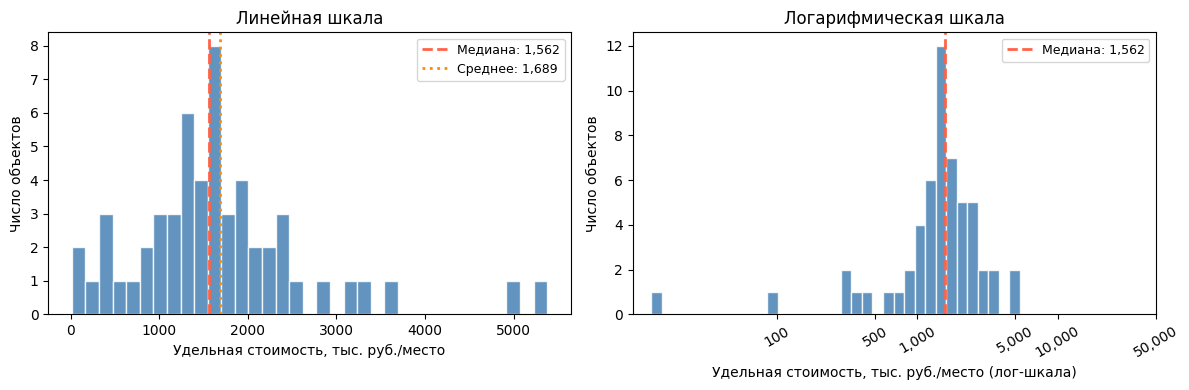

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(df["ucb_tys"], bins=35, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(df["ucb_tys"].median(), color="tomato", lw=2, linestyle="--",
           label=f"Медиана: {df['ucb_tys'].median():,.0f}")
ax.axvline(df["ucb_tys"].mean(), color="darkorange", lw=2, linestyle=":",
           label=f"Среднее: {df['ucb_tys'].mean():,.0f}")
ax.set_xlabel("Удельная стоимость, тыс. руб./место")
ax.set_ylabel("Число объектов")
ax.set_title("Линейная шкала")
ax.legend(fontsize=9)

ax = axes[1]
log_vals = np.log10(df["ucb_tys"].clip(lower=1))
ax.hist(log_vals, bins=35, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(np.log10(df["ucb_tys"].median()), color="tomato", lw=2, linestyle="--",
           label=f"Медиана: {df['ucb_tys'].median():,.0f}")
ticks = [100, 500, 1000, 5000, 10000, 50000]
ax.set_xticks([np.log10(t) for t in ticks])
ax.set_xticklabels([f"{t:,}" for t in ticks], rotation=30)
ax.set_xlabel("Удельная стоимость, тыс. руб./место (лог-шкала)")
ax.set_ylabel("Число объектов")
ax.set_title("Логарифмическая шкала")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

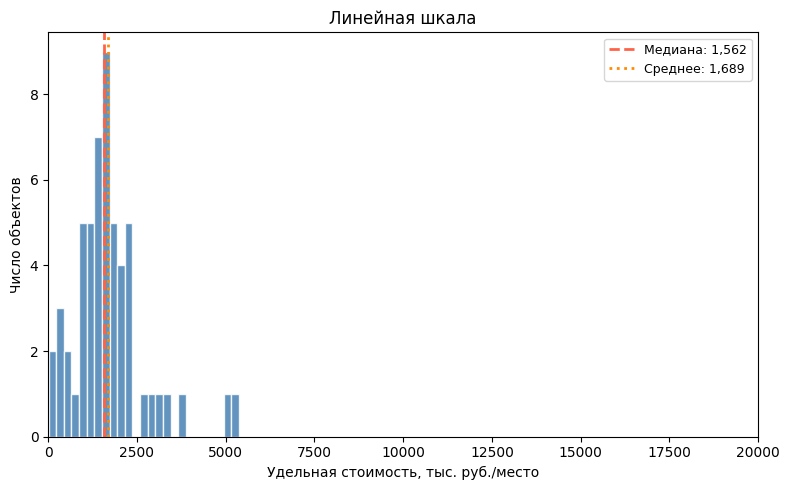

In [109]:
fig, ax = plt.subplots(figsize=(8, 5)) 

ax.hist(df["ucb_tys"], bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(df["ucb_tys"].median(), color="tomato", lw=2, linestyle="--",
           label=f"Медиана: {df['ucb_tys'].median():,.0f}")
ax.axvline(df["ucb_tys"].mean(), color="darkorange", lw=2, linestyle=":",
           label=f"Среднее: {df['ucb_tys'].mean():,.0f}")

ax.set_xlabel("Удельная стоимость, тыс. руб./место")
ax.set_ylabel("Число объектов")
ax.set_title("Линейная шкала")
ax.set_xlim(0, 20000)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

### Региональные различия удельной стоимости

Проверяю H1a: значимо ли различаются регионы по удельной стоимости, использую тест Краскела-Уоллиса, потому что данные не нормально распределены и групп много

In [110]:
reg_stats = df.groupby("region_short")["ucb_tys"].agg(
    n="count", медиана="median", среднее="mean", ст_откл="std"
).round(0)
reg_stats["Q25"] = df.groupby("region_short")["ucb_tys"].quantile(0.25).round(0)
reg_stats["Q75"] = df.groupby("region_short")["ucb_tys"].quantile(0.75).round(0)
reg_stats = reg_stats.sort_values("медиана", ascending=False)

print("Удельная стоимость по регионам (тыс. руб./место):")
print(reg_stats.to_string())

Удельная стоимость по регионам (тыс. руб./место):
                     n  медиана  среднее  ст_откл     Q25     Q75
region_short                                                     
Пензенская обл.      2   2348.0   2348.0    377.0  2215.0  2482.0
Пермский край       10   1996.0   2430.0   1317.0  1643.0  3189.0
Чувашия              4   1894.0   1867.0    489.0  1512.0  2249.0
Удмуртия             5   1686.0   1414.0    600.0  1417.0  1743.0
Ульяновская обл.     2   1536.0   1536.0     69.0  1512.0  1560.0
Оренбургская обл.    4   1514.0   1548.0    248.0  1421.0  1641.0
Башкортостан         6   1420.0   2097.0   1681.0  1190.0  2132.0
Нижегородская обл.   7   1382.0   1314.0    690.0  1121.0  1782.0
Кировская обл.       2   1351.0   1351.0    441.0  1195.0  1507.0
Марий Эл             3   1228.0   1455.0    821.0   999.0  1797.0
Саратовская обл.     3   1082.0   1058.0     50.0  1041.0  1087.0
Мордовия             6    945.0   1290.0   1221.0   375.0  2045.0
Татарстан            1    

Тест Краскела-Уоллиса — проверяем, есть ли значимые различия между регионами:

In [111]:
groups_reg = [grp["ucb_tys"].values for _, grp in df.groupby("region_short") if len(grp) >= 2]
kw_stat, kw_pval = stats.kruskal(*groups_reg)
print(f"H={kw_stat:.2f}, p={kw_pval:.4f}")

H=12.73, p=0.3114


Вывод: различия не достигают уровня значимости $\alpha$=0.05

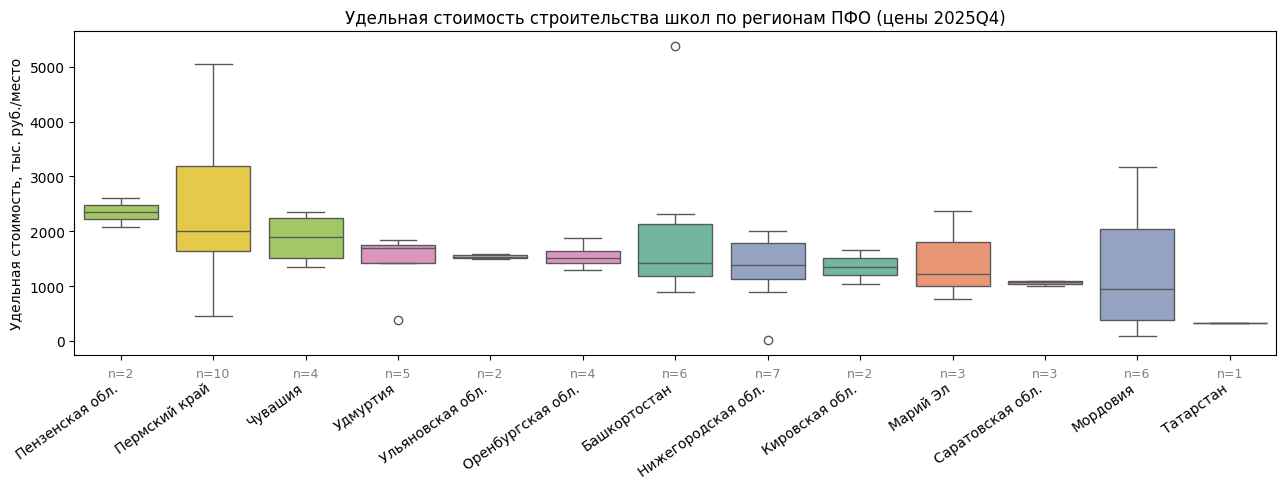

In [112]:
reg_order = reg_stats.index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x="region_short", y="ucb_tys", order=reg_order,
            hue="region_short", legend=False, palette="Set2", ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость строительства школ по регионам ПФО (цены 2025Q4)")

ax.tick_params(axis='x', pad=15) 
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")

ymin, ymax = ax.get_ylim()
for i, reg in enumerate(reg_order):
    n = int(reg_stats.loc[reg, "n"])
    ax.text(i, ymin-ymax*0.04, f"n={n}", 
            ha="center", va="top", 
            fontsize=9, color="gray")

fig.tight_layout()
plt.show()

Без выбросов:

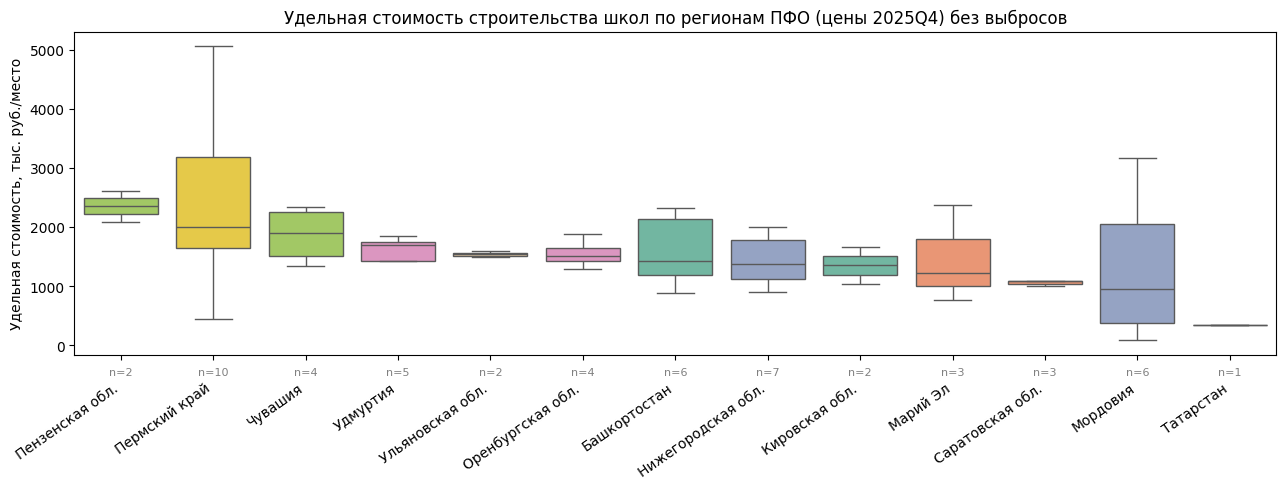

In [113]:
reg_order = reg_stats.index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x="region_short", y="ucb_tys", order=reg_order,
            hue="region_short", legend=False, palette="Set2", ax=ax, showfliers=False)
ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость строительства школ по регионам ПФО (цены 2025Q4) без выбросов")
ax.tick_params(axis='x', pad=15) 
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")

ymin, ymax = ax.get_ylim()
for i, reg in enumerate(reg_order):
    n = int(reg_stats.loc[reg, "n"])
    ax.text(i, ymin - ymax * 0.04, f"n={n}", ha="center", va="top", fontsize=8, color="gray")

fig.tight_layout()
plt.show()

### Различия по типу работ

H1b: различается ли стоимость в зависимости от того, включает ли контракт проектирование (ПИР+строительство) или только строительство, для двух групп использую тест Манна-Уитни

In [114]:
type_stats = (
    df.groupby("work_type_ru")["ucb_tys"]
    .agg(["count", "median", "mean", "std"])
    .round(0)
)

type_stats.columns = ["n", "медиана", "среднее", "ст.откл."]
type_stats = type_stats.sort_values("медиана", ascending=False)

print("Удельная стоимость по типу работ (тыс. руб./место):")
print(type_stats.to_string())

Удельная стоимость по типу работ (тыс. руб./место):
                           n  медиана  среднее  ст.откл.
work_type_ru                                            
ПИР + строительство       13   1743.0   1686.0     367.0
Новое строительство       41   1557.0   1697.0    1180.0
Завершение строительства   1   1417.0   1417.0       NaN


Манн-Уитни: новое строительство vs ПИР+строительство

In [115]:
nc_vals = df[df["work_type"] == "new_construction"]["ucb_tys"]
dc_vals = df[df["work_type"] == "design_and_construction"]["ucb_tys"]

In [116]:
mw_stat, mw_pval = None, None
mw_stat, mw_pval = stats.mannwhitneyu(nc_vals, dc_vals, alternative="two-sided")
print(f"U={mw_stat:.0f}, p={mw_pval:.4f}")
print(f"Медианы: новое={nc_vals.median():,.0f}, ПИР+стр={dc_vals.median():,.0f} тыс. руб./место")
print(f"p-value: {mw_pval}")

U=229, p=0.4541
Медианы: новое=1,557, ПИР+стр=1,743 тыс. руб./место
p-value: 0.45410085221486396


Вывод: различие не значимо

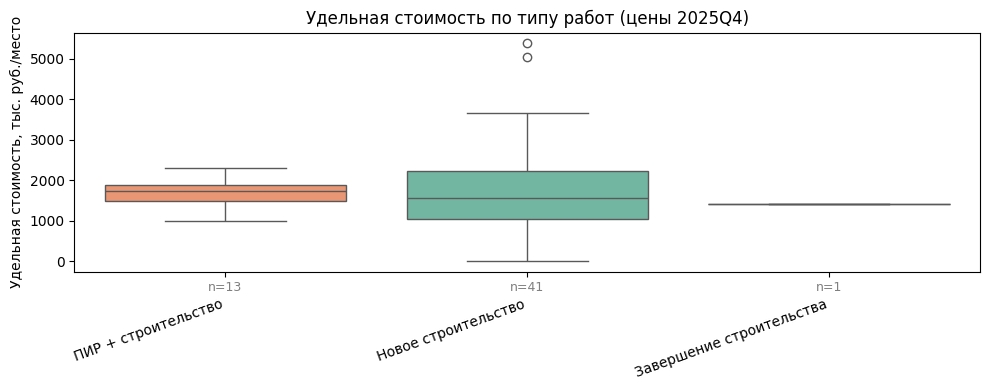

In [117]:
wt_order = type_stats.index.tolist()
df_wt = df[df["work_type_ru"].isin(wt_order)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df_wt, x="work_type_ru", y="ucb_tys", order=wt_order,
            hue="work_type_ru", legend=False, palette="Set2", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость по типу работ (цены 2025Q4)")

ax.tick_params(axis='x', pad=15) 
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

ymin, ymax = ax.get_ylim()
for i, wt in enumerate(wt_order):
    n = int(type_stats.loc[wt, "n"])
    ax.text(i, ymin - ymax * 0.04, f"n={n}", ha="center", va="top", fontsize=9, color="gray")

fig.tight_layout()
plt.show()

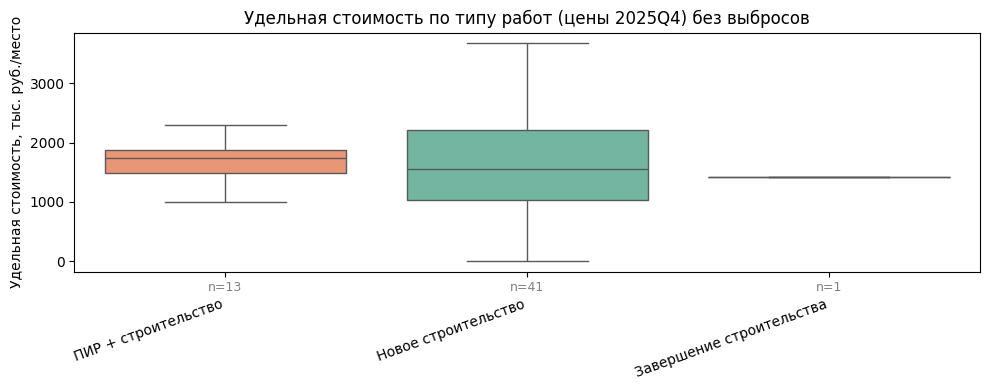

In [118]:
wt_order = type_stats.index.tolist()
df_wt = df[df["work_type_ru"].isin(wt_order)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df_wt, x="work_type_ru", y="ucb_tys", order=wt_order,
            hue="work_type_ru", legend=False, palette="Set2", ax=ax, showfliers=False)
ax.set_xlabel("")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость по типу работ (цены 2025Q4) без выбросов")
ax.tick_params(axis='x', pad=15) 
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

ymin, ymax = ax.get_ylim()
for i, wt in enumerate(wt_order):
    n = int(type_stats.loc[wt, "n"])
    ax.text(i, ymin - ymax * 0.04, f"n={n}", ha="center", va="top", fontsize=9, color="gray")

fig.tight_layout()
plt.show()

### Конкуренция и удельная стоимость

H2: есть ли связь между уровнем конкуренции (снижение от НМЦК) и удельной стоимостью. Корреляция Спирмена подходит, потому что распределение данных ненормально и есть много нулей (несостоявшиеся торги)

In [119]:
df_comp = df[df["discount_pct_mean"].notna() & (df["discount_pct_mean"] >= 0)].copy()
print(f"Объектов с данными о конкуренции: {len(df_comp)}")
print(f"Медианная скидка: {df_comp['discount_pct_mean'].median()*100:.3f}%")
print(f"Скидка = 0 (нет торгов): {(df_comp['discount_pct_mean'] == 0).sum()} объектов")

Объектов с данными о конкуренции: 25
Медианная скидка: 0.000%
Скидка = 0 (нет торгов): 13 объектов


In [120]:
rho_comp, pval_comp = stats.spearmanr(df_comp["discount_pct_mean"], df_comp["ucb_tys"])
print(f"Корреляция Спирмена (скидка, уд.стоимость): ρ={rho_comp:.3f}, p={pval_comp:.4f}")

if rho_comp < 0:
    print("Направление: отрицательная (больше скидка - ниже стоимость)")
else:
    print("Направление: положительная (больше скидка - выше стоимость)")

if pval_comp < 0.05:
    print("Статистически значимая (α=0.05)")
else:
    print("Статистически незначимая (α=0.05)")

Корреляция Спирмена (скидка, уд.стоимость): ρ=-0.040, p=0.8501
Направление: отрицательная (больше скидка - ниже стоимость)
Статистически незначимая (α=0.05)


Делим на 3 группы по уровню конкуренции

In [121]:
median_nonzero = df_comp.loc[df_comp["discount_pct_mean"] > 0, "discount_pct_mean"].median()

def competition_group(d):
    if d == 0:
        return "Нет торгов (скидка = 0)"
    elif d <= median_nonzero:
        return "Низкая (скидка ≤ медианы)"
    else:
        return "Высокая (скидка > медианы)"

df_comp["competition"] = df_comp["discount_pct_mean"].apply(competition_group)
comp_order = ["Нет торгов (скидка = 0)", "Низкая (скидка ≤ медианы)", "Высокая (скидка > медианы)"]

comp_tab = (
    df_comp.groupby("competition", observed=True)["ucb_tys"]
    .agg(["count", "median", "mean"]).round(0)
    .reindex(comp_order)
)

comp_tab.columns = ["n", "медиана", "среднее"]
print(f"Медианная скидка среди конкурентных торгов: {median_nonzero*100:.2f}%")

Медианная скидка среди конкурентных торгов: 0.65%


In [122]:
print("Удельная стоимость по уровню конкуренции:")
print(comp_tab.to_string())

Удельная стоимость по уровню конкуренции:
                             n  медиана  среднее
competition                                     
Нет торгов (скидка = 0)     13   1557.0   1836.0
Низкая (скидка ≤ медианы)    6   1736.0   2252.0
Высокая (скидка > медианы)   6   1690.0   1541.0


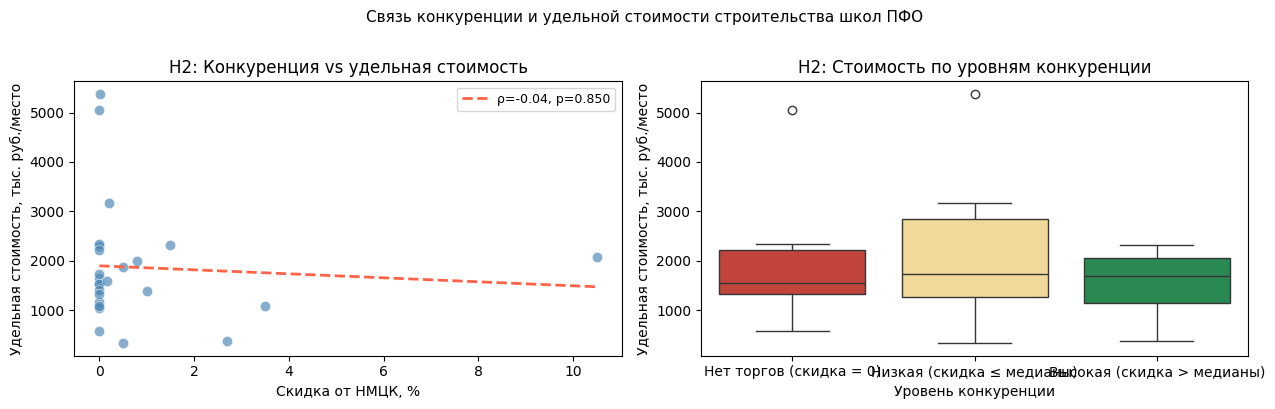

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(
    df_comp["discount_pct_mean"] * 100, df_comp["ucb_tys"],
    alpha=0.65, s=55, color="steelblue", edgecolors="white", linewidths=0.5
)
x_vals = df_comp["discount_pct_mean"] * 100
m, b = np.polyfit(x_vals, df_comp["ucb_tys"], 1)
xs = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(xs, m * xs + b, color="tomato", lw=2, linestyle="--",
        label=f"ρ={rho_comp:.2f}, p={pval_comp:.3f}")
ax.set_xlabel("Скидка от НМЦК, %")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("H2: Конкуренция vs удельная стоимость")
ax.legend(fontsize=9)

ax = axes[1]
sns.boxplot(
    data=df_comp, x="competition", y="ucb_tys",
    order=comp_order, hue="competition", legend=False,
    palette=["#d73027", "#fee08b", "#1a9850"], ax=ax
)
ax.set_xlabel("Уровень конкуренции")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("H2: Стоимость по уровням конкуренции")

fig.suptitle("Связь конкуренции и удельной стоимости строительства школ ПФО",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

### Временная динамика удельной стоимости

In [124]:
yr_stats = (
    df.groupby("year")["ucb_tys"]
    .agg(["count", "median", "mean",
          lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    .round(0)
)

yr_stats.columns = ["n", "медиана", "среднее", "Q25", "Q75"]
print("Удельная стоимость по годам (тыс. руб./место, цены 2025Q4):")
print(yr_stats.to_string())

Удельная стоимость по годам (тыс. руб./место, цены 2025Q4):
       n  медиана  среднее     Q25     Q75
year                                      
2022  19   1350.0   1556.0  1120.0  1650.0
2023   9   1465.0   1692.0  1039.0  1845.0
2024  10   1715.0   1627.0  1542.0  1964.0
2025  17   1686.0   1873.0  1284.0  2324.0


In [125]:
rho_time, pval_time = stats.spearmanr(df["year"], df["ucb_tys"])
print(f"Корреляция Спирмена (год, уд.стоимость): ρ={rho_time:.3f}, p={pval_time:.4f}")

time_sig = "значимый тренд" if pval_time < 0.05 else "значимый тренд отсутствует"
print(f"Вывод: {time_sig} (α=0.05)")

Корреляция Спирмена (год, уд.стоимость): ρ=0.211, p=0.1225
Вывод: значимый тренд отсутствует (α=0.05)


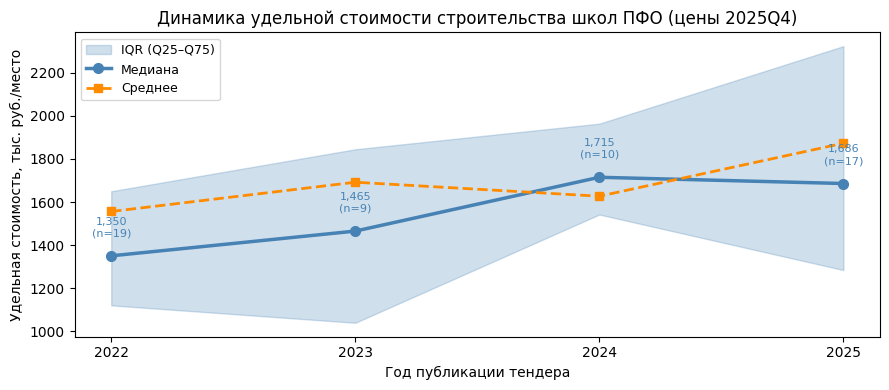

In [126]:
fig, ax = plt.subplots(figsize=(9, 4))

years = yr_stats.index.tolist()
medians = yr_stats["медиана"].tolist()
q25_yr = yr_stats["Q25"].tolist()
q75_yr = yr_stats["Q75"].tolist()
means = yr_stats["среднее"].tolist()
ns = yr_stats["n"].tolist()

ax.fill_between(years, q25_yr, q75_yr, alpha=0.25, color="steelblue", label="IQR (Q25–Q75)")
ax.plot(years, medians, marker="o", color="steelblue", lw=2.5, markersize=7, label="Медиана")
ax.plot(years, means, marker="s", color="darkorange",
        lw=2, markersize=6, linestyle="--", label="Среднее")

for yr, med, n in zip(years, medians, ns):
    ax.annotate(f"{med:,.0f}\n(n={int(n)})", xy=(yr, med),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=8, color="steelblue")

ax.set_xlabel("Год публикации тендера")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Динамика удельной стоимости строительства школ ПФО (цены 2025Q4)")
ax.set_xticks(years)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

### Эффект масштаба: мощность -> удельная стоимость

In [127]:
rho_scale, pval_scale = stats.spearmanr(df["places"], df["ucb_tys"])
print(f"Корреляция Спирмена (мощность, уд.стоимость): ρ={rho_scale:.3f}, p={pval_scale:.4f}")

scale_sig = "значимый эффект масштаба" if pval_scale < 0.05 else "не значимо"
scale_dir = "отрицательная" if rho_scale < 0 else "положительная"
print(f"Вывод: {scale_dir} зависимость, {scale_sig} (α=0.05)")

Корреляция Спирмена (мощность, уд.стоимость): ρ=-0.404, p=0.0022
Вывод: отрицательная зависимость, значимый эффект масштаба (α=0.05)


In [128]:
df["size_group"] = pd.cut(
    df["places"],
    bins=[0, 300, 600, 1000, 2000, 5000],
    labels=["≤300 мест", "301–600", "601–1000", "1001–2000", ">2000"]
)

size_tab = df.groupby("size_group", observed=True)["ucb_tys"].agg(["count","median","mean"]).round(0)
size_tab.columns = ["n", "медиана", "среднее"]
print("Удельная стоимость по мощности объекта:")
print(size_tab.to_string())

Удельная стоимость по мощности объекта:
             n  медиана  среднее
size_group                      
≤300 мест   12   2328.0   2628.0
301–600     19   1417.0   1461.0
601–1000     7   1594.0   1599.0
1001–2000   17   1382.0   1318.0


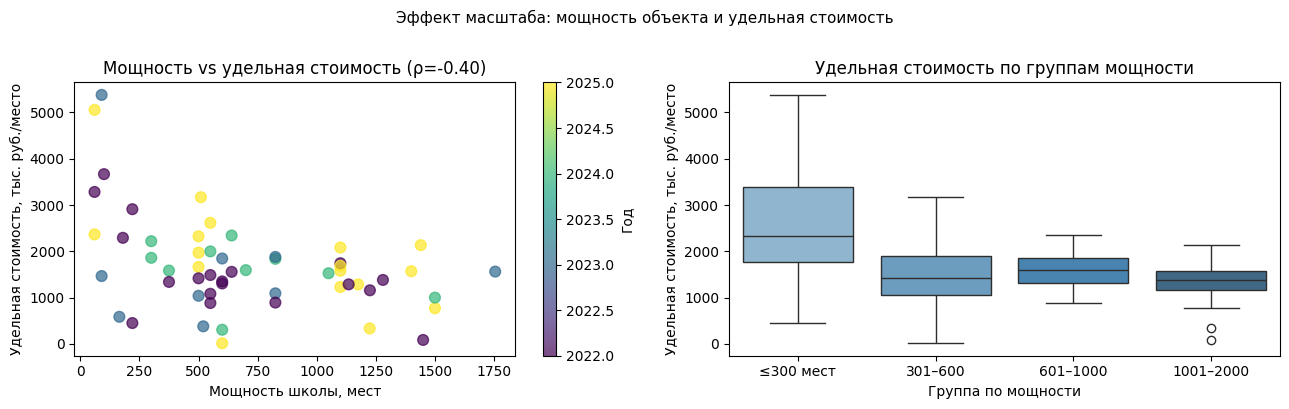

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
sc = ax.scatter(df["places"], df["ucb_tys"], c=df["year"],
                cmap="viridis", alpha=0.7, s=60)
plt.colorbar(sc, ax=ax, label="Год")
ax.set_xlabel("Мощность школы, мест")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title(f"Мощность vs удельная стоимость (ρ={rho_scale:.2f})")

ax = axes[1]
sns.boxplot(
    data=df[df["size_group"].notna()],
    x="size_group", y="ucb_tys",
    order=["≤300 мест", "301–600", "601–1000", "1001–2000"],
    hue="size_group", legend=False, palette="Blues_d", 
    ax=ax, width=0.8, dodge=False
)
ax.set_xlabel("Группа по мощности")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость по группам мощности")

fig.suptitle("Эффект масштаба: мощность объекта и удельная стоимость",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

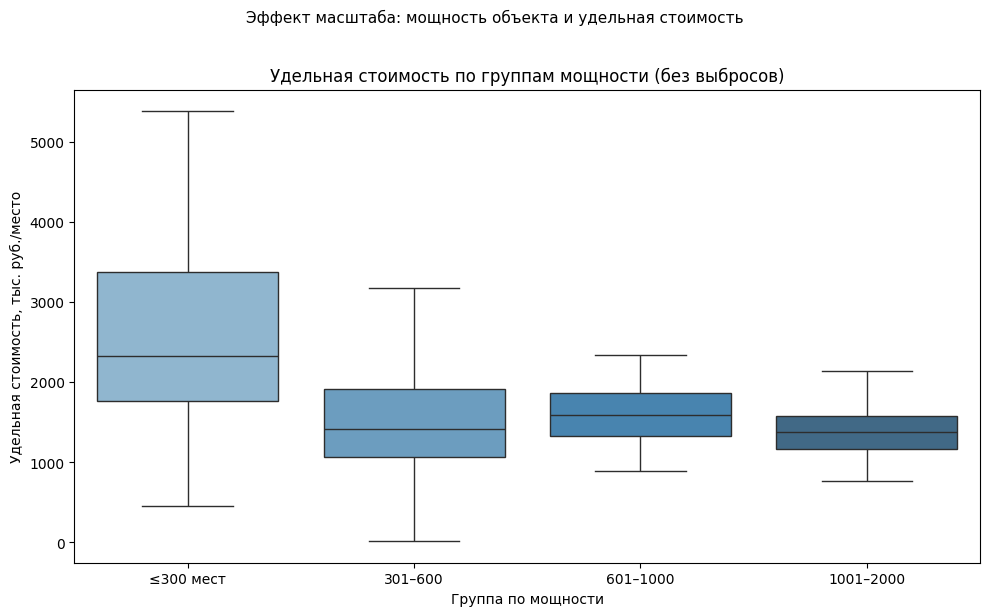

In [130]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df[df["size_group"].notna()],
    x="size_group", 
    y="ucb_tys",
    order=["≤300 мест", "301–600", "601–1000", "1001–2000"],
    hue="size_group", 
    legend=False, 
    palette="Blues_d",
    ax=ax,
    showfliers=False,
    width=0.8,
    dodge=False
)

ax.set_xlabel("Группа по мощности")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Удельная стоимость по группам мощности (без выбросов)")

fig.suptitle("Эффект масштаба: мощность объекта и удельная стоимость",
             fontsize=11, y=1.02)

fig.tight_layout()
plt.show()

### Регрессионный анализ: объяснение вариации удельной стоимости

Чтобы проверить H1 («после учета характеристик проекта разброс стоимости снижается»), строю 3 OLS-регрессии на логарифмированных переменных, зависимая переменная — `ln(ucb_tys)` (логарифм удельной стоимости)

Коэффициент при `ln(places)` можно интерпретировать как эластичность из-за логарифмирования: на сколько процентов меняется удельная стоимость при увеличении мощности на 1%

- M1: только масштаб — `ln_ucb ~ ln_places`
- M2: масштаб + год — добавляю год как контроль временного тренда
- M3: масштаб + год + тип работ — добавляю флаг «новое строительство»

In [131]:
import statsmodels.formula.api as smf

df["ln_ucb"] = np.log(df["ucb_tys"])
df["ln_places"] = np.log(df["places"])
df["work_nc"] = (df["work_type"] == "new_construction").astype(int)

m1 = smf.ols("ln_ucb ~ ln_places", data=df).fit()
m2 = smf.ols("ln_ucb ~ ln_places + year", data=df).fit()
m3 = smf.ols("ln_ucb ~ ln_places + year + work_nc", data=df).fit()

print(f"{'':22s} {'M1':>10s} {'M2':>10s} {'M3':>10s}")
print("-" * 54)

all_vars = ["Intercept", "ln_places", "year", "work_nc"]
var_labels = {
    "Intercept": "Константа",
    "ln_places": "ln(места)",
    "year": "Год",
    "work_nc": "Новое стр-во (1=да)",
}

for v in all_vars:
    row = f"{var_labels[v]:22s}"
    
    for m in [m1, m2, m3]:
        if v in m.params:
            b, p = m.params[v], m.pvalues[v]
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else " "
            row += f"  {b:+.3f}{sig:3s}"
        else:
            row += f"  {'—':>8s}"

    print(row)

                               M1         M2         M3
------------------------------------------------------
Константа               +9.271***  -99.642     -194.393   
ln(места)               -0.334*    -0.346*    -0.413** 
Год                            —  +0.054     +0.101   
Новое стр-во (1=да)            —         —  -0.535   


In [132]:
print(f"{'':22s} {'M1':>10s} {'M2':>10s} {'M3':>10s}")
print("-" * 55)

for label, key in [("n", None), ("R²", "rsquared"), ("adj. R²", "rsquared_adj")]:
    row = f"{label:22s}"
    
    for m in [m1, m2, m3]:
        if key is None:
            row += f"  {int(m.nobs):>9d}"
        else:
            row += f"  {getattr(m, key):>9.3f}"
    print(row)

                               M1         M2         M3
-------------------------------------------------------
n                              55         55         55
R²                          0.098      0.103      0.159
adj. R²                     0.081      0.069      0.110


In [133]:
raw_cv = df["ucb_tys"].std() / df["ucb_tys"].mean()
print(f"Исходный CV удельной стоимости (уровень): {raw_cv:.2f}")
print(f"Остаточный std(ln) M1 (только масштаб): {m1.resid.std():.3f}")
print(f"Остаточный std(ln) M3 (все контроли): {m3.resid.std():.3f}")
print(f"M3 объясняет {m3.rsquared:.1%} дисперсии ln(ucb)")

Исходный CV удельной стоимости (уровень): 0.61
Остаточный std(ln) M1 (только масштаб): 0.896
Остаточный std(ln) M3 (все контроли): 0.866
M3 объясняет 15.9% дисперсии ln(ucb)


Проверяю, нет ли явных паттернов:

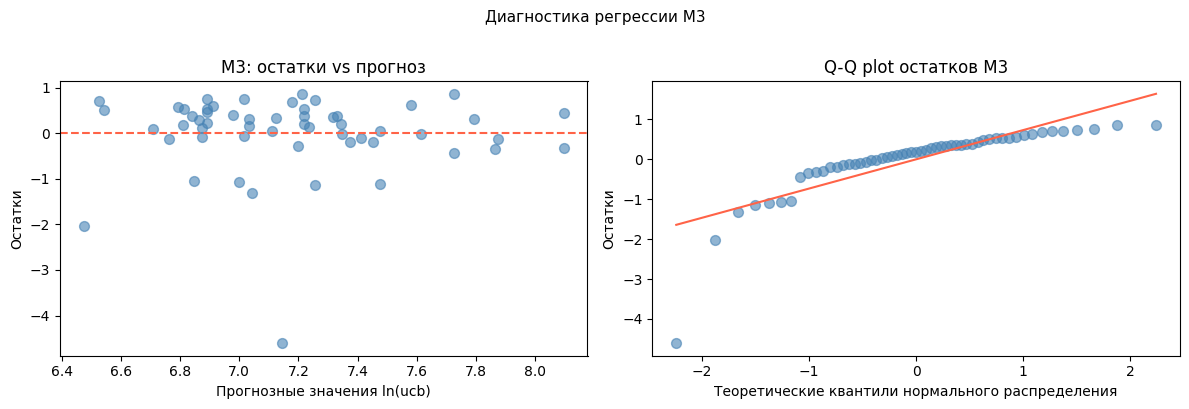

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(m3.fittedvalues, m3.resid, alpha=0.6, color="steelblue", s=50)
ax.axhline(0, color="tomato", lw=1.5, linestyle="--")
ax.set_xlabel("Прогнозные значения ln(ucb)")
ax.set_ylabel("Остатки")
ax.set_title("M3: остатки vs прогноз")

ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(m3.resid, dist="norm")
ax.scatter(osm, osr, alpha=0.6, color="steelblue", s=50)
ax.plot(osm, slope * np.array(osm) + intercept, color="tomato", lw=1.5)
ax.set_xlabel("Теоретические квантили нормального распределения")
ax.set_ylabel("Остатки")
ax.set_title("Q-Q plot остатков M3")

fig.suptitle("Диагностика регрессии M3", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

### Выявление аномалий (Reference Class Forecasting / IQR-метод)

Выявляю аномалии методом IQR-fence на референсном классе (новое строительство + ПИР+строительство, 100–2000 мест, без пакетных закупок). Граница: выше P75 + 1.5·IQR — высокая стоимость, ниже P25 − 1.5·IQR — низкая

In [135]:
ref_class = df[
    df["work_type"].isin(["new_construction", "design_and_construction"]) &
    ~df["any_package"] &
    df["places"].between(100, 2000)
].copy()
print(f"Референсный класс: {len(ref_class)} объектов")

Референсный класс: 49 объектов


In [136]:
rcf_p10 = ref_class["ucb_tys"].quantile(0.10)
rcf_p25 = ref_class["ucb_tys"].quantile(0.25)
rcf_med = ref_class["ucb_tys"].quantile(0.50)
rcf_p75 = ref_class["ucb_tys"].quantile(0.75)
rcf_p90 = ref_class["ucb_tys"].quantile(0.90)
rcf_iqr = rcf_p75 - rcf_p25
rcf_fence_high = rcf_p75 + 1.5 * rcf_iqr
rcf_fence_low = max(rcf_p25 - 1.5 * rcf_iqr, 100)

print(f"Параметры референсного класса (тыс. руб./место):")
print(f"  P10={rcf_p10:,.0f}  P25={rcf_p25:,.0f}  P50={rcf_med:,.0f}  P75={rcf_p75:,.0f}  P90={rcf_p90:,.0f}")
print(f"  IQR={rcf_iqr:,.0f}")
print(f"  Граница высокой стоимости: > {rcf_fence_high:,.0f} тыс. руб./место")
print(f"  Граница низкой стоимости: < {rcf_fence_low:,.0f} тыс. руб./место")

Параметры референсного класса (тыс. руб./место):
  P10=436  P25=1,082  P50=1,557  P75=1,879  P90=2,327
  IQR=796
  Граница высокой стоимости: > 3,073 тыс. руб./место
  Граница низкой стоимости: < 100 тыс. руб./место


In [137]:
df["anomaly_high"] = df["ucb_tys"] > rcf_fence_high
df["anomaly_low"] = df["ucb_tys"] < rcf_fence_low
df["anomaly"] = df["anomaly_high"] | df["anomaly_low"]

print(f"Аномалии во всём датасете ({len(df)} объектов):")
print(f"  Высокая стоимость: {df['anomaly_high'].sum()} объектов")
print(f"  Низкая стоимость: {df['anomaly_low'].sum()} объектов")
print(f"  Итого аномальных: {df['anomaly'].sum()} ({df['anomaly'].mean():.1%})")

Аномалии во всём датасете (55 объектов):
  Высокая стоимость: 5 объектов
  Низкая стоимость: 2 объектов
  Итого аномальных: 7 (12.7%)


In [138]:
anomalies = df[df["anomaly"]].copy()
anomalies["Тип аномалии"] = "низкая" 
anomalies.loc[anomalies["anomaly_high"], "Тип аномалии"] = "высокая"

anomalies["Скидка %"] = (anomalies["discount_pct_mean"] * 100).round(1)
rename_map = {
    "region_short": "Регион",
    "publication_name": "Название",
    "places": "Мест",
    "year": "Год",
    "ucb_tys": "Уд.стоимость"
}
anomalies = anomalies.rename(columns=rename_map)

cols = ["Регион", "Название", "Мест", "Год", "Уд.стоимость", "Скидка %", "Тип аномалии"]
anomalies = anomalies.sort_values("Уд.стоимость", ascending=False)

print(anomalies[cols].to_string(index=False, float_format="%.0f"))

            Регион                                                                                                                                                                                                                                                     Название  Мест  Год  Уд.стоимость  Скидка % Тип аномалии
      Башкортостан Выполнение строительно-монтажных, пусконаладочных работ, поставка оборудования, неразрывно связанного с производством работ, по объекту "Строительство школы на 90 мест с детским садом на 40 мест в с. Новый Бердяш в муниципальном районе Караидельский...    90 2023          5379         0      высокая
     Пермский край                                                                                                                                 ВЫПОЛНЕНИЕ РАБОТ ПО ОБЪЕКТУ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА: «СТРОИТЕЛЬСТВО ШКОЛЫ В Д. НИЖНЯЯ ТАЛИЦА ОЧЕРСКОГО ГОРОДСКОГО ОКРУГА»    60 2025          5055         0      высокая
     Пермский край                      

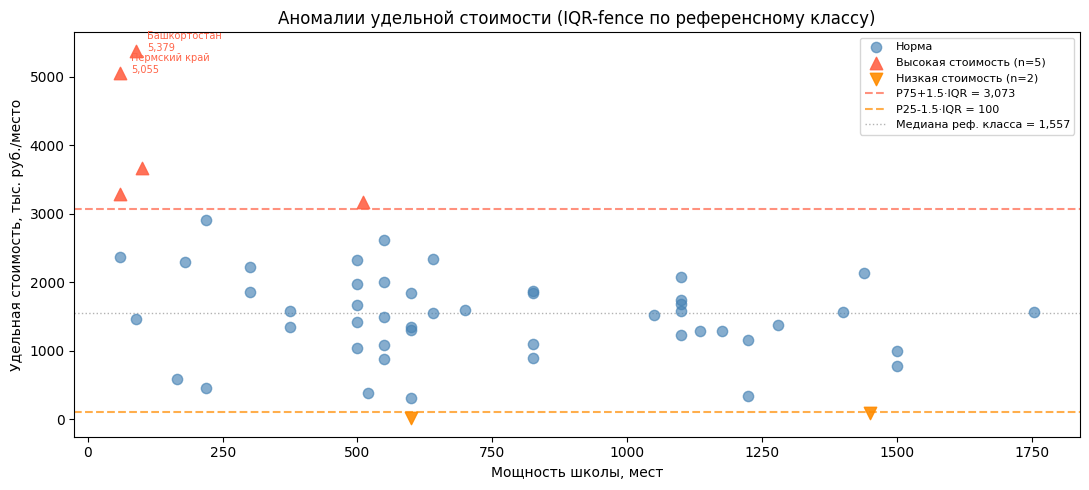

In [139]:
fig, ax = plt.subplots(figsize=(11, 5))

normal = df[~df["anomaly"]]
high = df[df["anomaly_high"]]
low = df[df["anomaly_low"]]

ax.scatter(normal["places"], normal["ucb_tys"],
           color="steelblue", alpha=0.65, s=55, label="Норма", zorder=3)
ax.scatter(high["places"], high["ucb_tys"],
           color="tomato", alpha=0.9, s=80, marker="^",
           label=f"Высокая стоимость (n={len(high)})", zorder=4)
ax.scatter(low["places"], low["ucb_tys"],
           color="darkorange", alpha=0.9, s=80, marker="v",
           label=f"Низкая стоимость (n={len(low)})", zorder=4)

ax.axhline(rcf_fence_high, color="tomato", lw=1.5, linestyle="--", alpha=0.7,
           label=f"P75+1.5·IQR = {rcf_fence_high:,.0f}")
ax.axhline(rcf_fence_low, color="darkorange", lw=1.5, linestyle="--", alpha=0.7,
           label=f"P25-1.5·IQR = {rcf_fence_low:,.0f}")
ax.axhline(rcf_med, color="gray", lw=1, linestyle=":", alpha=0.6,
           label=f"Медиана реф. класса = {rcf_med:,.0f}")

strict_high = rcf_p75 + 3.0 * rcf_iqr
for _, row in df[df["ucb_tys"] > strict_high].iterrows():
    ax.annotate(
        f"{row['region_short']}\n{row['ucb_tys']:,.0f}",
        xy=(row["places"], row["ucb_tys"]),
        xytext=(8, 0), textcoords="offset points",
        fontsize=7, color="tomato"
    )

ax.set_xlabel("Мощность школы, мест")
ax.set_ylabel("Удельная стоимость, тыс. руб./место")
ax.set_title("Аномалии удельной стоимости (IQR-fence по референсному классу)")
ax.legend(fontsize=8, loc="upper right")

fig.tight_layout()
plt.show()

### Анализ аномальных объектов

Было исправлено 25 значений `places` в исходном датасете (точность doc-извлечения (не из названия публикации) оказалась 25%, в другом ноутбуке `analysis_05_places_extaraction.ipynb` повышаю это качество) аномалий стало 7 вместо 10. Для оставшихся 7 объектов смотрю причины

In [140]:
anomalies_detail = df[df["anomaly"]][[
    "object_id", "publication_name", "region_short",
    "places", "ucb_tys", "discount_pct_mean"
]].copy()

In [141]:
header = f"{'object_id':<10} {'publication_name':<160} {'region':<15} {'places':<8} {'ucb_tys':<10} {'discount':<10}"
print(header)

for row in anomalies_detail.itertuples():
    print(f"{row.object_id:<10} {row.publication_name:<160} {row.region_short:<15} {row.places:<8} {row.ucb_tys:<10.2f} {row.discount_pct_mean:<10.2f}")

object_id  publication_name                                                                                                                                                 region          places   ucb_tys    discount  
obj_0010   Выполнение строительно-монтажных, пусконаладочных работ, поставка оборудования, неразрывно связанного с производством работ, по объекту "Строительство школы на 90 мест с детским садом на 40 мест в с. Новый Бердяш в муниципальном районе Караидельский... Башкортостан    90.0     5379.13    0.00      
obj_0021   Выполнение подрядных работ по объекту "Строительство здания средней школы на 600 мест по ул. Зорге в г. Саров Нижегородской области"                             Нижегородская обл. 600.0    12.62      nan       
obj_0028   Выполнение работ по строительству нового здания школы - детского сада в п. Сергеевский Гайнского муниципального округа                                           Пермский край   100.0    3667.56    nan       
obj_0067   ВЫПОЛНЕНИЕ РАБОТ П

#### Интерпретация аномалий высокой стоимости (5 объектов)

**Группа 1. Маленькие сельские школы (эффект масштаба)**

- obj_0067 (Пермский край, д. Нижняя Талица, 60 мест, 5055 тыс/место) и obj_0106 (Пермский край, с. Доег, 60 мест, 3283 тыс/место) — очень маленькие школы в отдаленных сельских населенных пунктах Пермского края. Постоянные издержки (проектирование, подключение сетей, фундамент) распределяются на 60 мест, поэтому такая высокая удельная стоимость

- obj_0028(Пермский край, п. Сергеевский, 100 мест, 3668 тыс/место) — маленькая школа в сельской местности. По названию — совмещенный объект (школа + детский сад), при этом в качестве мощности учтены только школьные места, что еще завышает показатель

- obj_0010 (Башкортостан, с. Новый Бердяш, 90 мест, 5379 тыс/место) — явно комбинированный контракт: «школа на 90 мест с детским садом на 40 мест». Стоимость всего контракта отнесена к 90 школьным местам — это неразделенный лот

**Группа 2. Крупная школа с необъяснимо высокой стоимостью**

- obj_0085 (Мордовия, г. Саранск, 510 мест, 3169 тыс/место) — мощность немаленькая, чтобы пропал эффект масштаба. Этот объект можно изучить подробнее, возможно там присутствует расширенная инженерная инфраструктура (в названии — «многопрофильная») / есть особое оборудование. Discount = 0 — единственный участник, конкуренции нет

### Интерпретация аномалий низкой стоимости (2 объекта)

- obj_0021 (Нижегородская обл., г. Саров, 600 мест, 12,6 тыс/место, 7,6 млн руб. всего). Г. Саров — ЗАТО (ядерный центр), где часть закупок проводится по закрытым процедурам. Возможно в базу попал контракт на отдельный вид работ (монтаж, поставка оборудования), а основные СМР закупались отдельно

- obj_0076 (Мордовия, г. Саранск, 1 450 мест, 85 тыс/место, 123 млн руб. всего). Опять же похоже, что в выборку попал частичный контракт (отдельный этап или вид работ)

Оба эти объекта — артефакты парсинга данных, а не реальные аномалии строительного рынка. При расширении выборки можно добавить фильтр на минимальную сумму контракта (например, > 50 млн руб)

### Доверительные интервалы для корреляций (бутстрап)

При маленьком числе наблюдений одна p-value мало что говорит - для корреляций Спирмена считаю бутстрап: много раз случайно выбираю строки с возвращением и каждый раз заново считаю $\rho$. По получившимся значениям беру 2.5\% и 97.5\% — это примерный 95\%-ный интервал для $\rho$

In [142]:
rng = np.random.default_rng(42)
N_BOOT = 2000

def boot_spearman(x, y, n_boot=N_BOOT):
    xy = pd.DataFrame({"x": x, "y": y}).dropna()
    n = len(xy)
    if n < 5:
        return None, None, n

    xs = xy["x"].to_numpy()
    ys = xy["y"].to_numpy()
    rhos = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        r, _ = stats.spearmanr(xs[idx], ys[idx])
        if np.isfinite(r):
            rhos.append(r)
    rhos = np.array(rhos)
    lo, hi = np.percentile(rhos, [2.5, 97.5])

    return lo, hi, n

95%-ные бутстрап-интервалы для ρ (Спирмен):

In [147]:
lo, hi, n = boot_spearman(df["places"], df["ucb_tys"])
print(f"Масштаб (места vs удельная стоимость): n={n}, точечная ρ={rho_scale:.3f}")
print(f"95% CI для ρ: [{lo:.3f}; {hi:.3f}]")

Масштаб (места vs удельная стоимость): n=55, точечная ρ=-0.404
95% CI для ρ: [-0.627; -0.123]


In [148]:
lo, hi, n = boot_spearman(df_comp["discount_pct_mean"], df_comp["ucb_tys"])
print(f"Конкуренция (скидка vs удельная стоимость): n={n}, точечная ρ={rho_comp:.3f}")
print(f"95% CI для ρ: [{lo:.3f}; {hi:.3f}]")

Конкуренция (скидка vs удельная стоимость): n=25, точечная ρ=-0.040
95% CI для ρ: [-0.426; 0.394]


In [149]:
lo, hi, n = boot_spearman(df["year"], df["ucb_tys"])
print(f"Время (год vs удельная стоимость): n={n}, точечная ρ={rho_time:.3f}")
print(f"95% CI для ρ: [{lo:.3f}; {hi:.3f}]")

Время (год vs удельная стоимость): n=55, точечная ρ=0.211
95% CI для ρ: [-0.056; 0.476]


In [150]:
df.to_csv(ROOT / "data_processed" / "analysis_objects_annotated.csv", index=False)